In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from neurocaps.extraction import TimeseriesExtractor
from neurocaps.utils import simulate_bids_dataset

/home/linjh/anaconda3/envs/neurocaps/lib/python3.14/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
OUTPUT_ROOT = Path("./outputs/PDNeuroCAPs")
EXTRACTION_DIR = OUTPUT_ROOT / "01_extraction"
CLUSTER_DIR = OUTPUT_ROOT / "02_clustering"
METRICS_DIR = OUTPUT_ROOT / "03_metrics"
LABELS_DIR = OUTPUT_ROOT / "04_framewise_labels"
TEMPLATES_DIR = OUTPUT_ROOT / "05_cap_templates"

for _dir in [OUTPUT_ROOT, EXTRACTION_DIR, CLUSTER_DIR, METRICS_DIR, LABELS_DIR, TEMPLATES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

# Import function implementations from scripts module
from scripts.notebook_utils import (
    get_roi_labels,
    save_subject_timeseries_csv,
    save_cluster_scores,
    save_predicted_labels,
    save_cap_templates,
)

FD QC: mean FD < 0.5 and FD<1.0 % > 98.0
Subject-level FD statistics exported: outputs/clinical_statistics/Subject_FD.csv
FD QC inclusion summary exported: outputs/clinical_statistics/FD_QC_Inclusion_Summary.csv
Table 3 FD statistics exported: outputs/clinical_statistics/Table3_QC_MeanFD_Long_Format.csv
Subject_FD rows: 715
---------------------------------------------------------------------------
             Group Direct_failed_count  Final_excluded_count  Total_count Direct_failed/Total Final_excluded/Total  Final_included_count                                                                                                Direct_failed_IDs                                                                                                                         Excluded_IDs
                HC                   1                     1          141               1/141                1/141                   140                                                                               

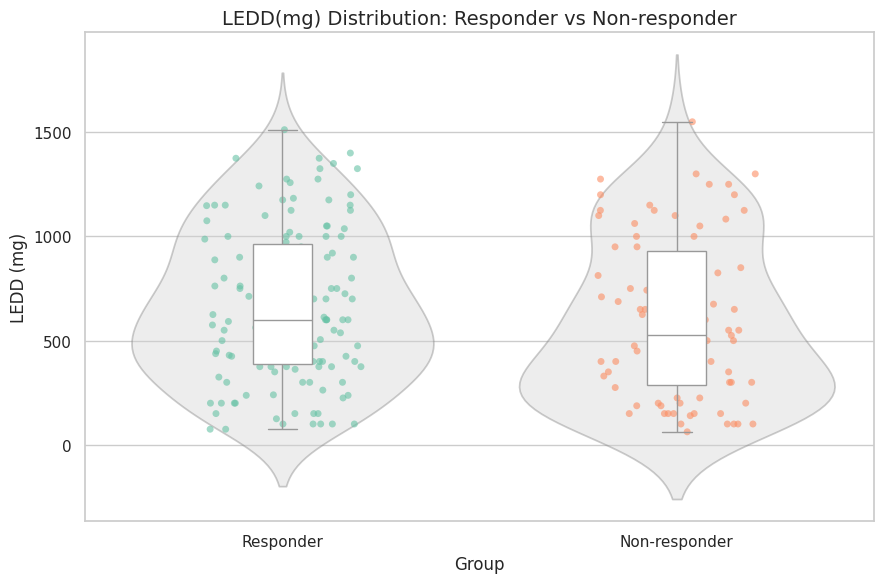

In [3]:
# Perform QC and statistical analysis of clinical variables
import importlib
from IPython.display import display
from scripts import FD_statistics, clinical_statistics_LEDD

# Reload so edits to the scripts (including QC thresholds) take effect on rerun.
importlib.reload(FD_statistics)
importlib.reload(clinical_statistics_LEDD)

# Generate Subject_FD.csv, the inclusion summary, and QC-filtered Table 3.
print("FD QC: mean FD <", FD_statistics.MEAN_FD_UPPER_LIMIT,
      "and FD<1.0 % >", FD_statistics.MIN_FD_BELOW_1_PERCENT)
FD_statistics.main_fd_analysis()
subject_fd_qc_path = FD_statistics.SUBJECT_FD_PATH
fd_qc_df = pd.read_csv(subject_fd_qc_path, dtype={"subject_id": "string"})

# Use this freshly generated QC table for clinical Tables 1 and 2.
clinical_statistics_LEDD.clinical_path = FD_statistics.CLINICAL_PATH
clinical_statistics_LEDD.subject_fd_path = subject_fd_qc_path
clinical_statistics_LEDD.output_path = FD_statistics.OUTPUT_DIR
clinical_statistics_LEDD.main()

In [4]:
# Set seed
np.random.seed(0)

# Generate a BIDS directory with fMRIPrep derivatives
# bids_root = simulate_bids_dataset(n_subs=3, n_runs=1, n_volumes=100, task_name="rest")
# print(f"BIDS dataset created at: {bids_root}")
bids_root = "./MyDataSet_Reorganized"

# Using custom A283 parcellation
from atlas283_custom_parcellation import ATLAS283_CUSTOM
import copy
parcel_approach = copy.deepcopy(ATLAS283_CUSTOM)

# List of fMRIPrep-derived confounds for nuisance regression
acompcor_names = [f"a_comp_cor_0{i}" for i in range(5)]
confound_names = ["cosine*", "trans*", "rot*", *acompcor_names]

# Initialize extractor with signal cleaning parameters
extractor = TimeseriesExtractor(
    space="MNI152NLin6Asym",
    parcel_approach=parcel_approach,
    confound_names=confound_names,
    standardize=True,
    # Disable NeuroCAPs internal FD QC; external QC is applied below.
    fd_threshold=None,
)

# Paths for the complete timeseries cache and external FD QC table
subject_ts_cache = EXTRACTION_DIR / "subject_timeseries.pkl"

# Clear cache if directory structure has changed
TimeseriesExtractor._call_layout.cache_clear()

# Check local cache before running extraction
if subject_ts_cache.exists():
    print(f"[INFO] Found cached timeseries: {subject_ts_cache}")
    extractor.subject_timeseries = str(subject_ts_cache)
    print("[INFO] Loaded subject_timeseries from cache. Skip get_bold().")
else:
    print("[INFO] Cache not found. Running get_bold().")
    extractor.get_bold(bids_dir=bids_root, task="rest", tr=0.735, n_cores=3, verbose=True)

    extractor.timeseries_to_pickle(
        output_dir=str(EXTRACTION_DIR),
        filename="subject_timeseries.pkl",
    )
    print(f"[INFO] Saved cache file: {subject_ts_cache}")

    # Save all extracted timeseries into per-subject/run files (csv + npz)
    first_subj = next(iter(extractor.subject_timeseries))
    first_run = next(iter(extractor.subject_timeseries[first_subj]))
    n_rois = extractor.subject_timeseries[first_subj][first_run].shape[1]
    roi_labels = get_roi_labels(parcel_approach, n_rois)
    ts_summary_df = save_subject_timeseries_csv(
        extractor.subject_timeseries,
        output_dir=EXTRACTION_DIR / "timeseries_files",
        roi_labels=roi_labels,
        save_wide_csv=True,
        save_long_csv=False,
        save_npz=True,
        write_index_json=True,
    )

required_qc_columns = {"subject_id", "run", "included"}
missing_qc_columns = required_qc_columns - set(fd_qc_df.columns)
if missing_qc_columns:
    raise ValueError(
        "Subject_FD.csv is missing required columns: "
        + ", ".join(sorted(missing_qc_columns))
    )

fd_qc_df["subject_id"] = fd_qc_df["subject_id"].str.strip()
fd_qc_df["run"] = fd_qc_df["run"].astype(str).str.strip()
included_status = fd_qc_df["included"].astype(str).str.strip().str.lower()
if not included_status.isin({"yes", "no"}).all():
    raise ValueError("Subject_FD.csv included column must contain only Yes or No.")
if fd_qc_df[["subject_id", "run"]].duplicated().any():
    raise ValueError("Subject_FD.csv contains duplicate subject_id/run rows.")
fd_qc_df["included_bool"] = included_status.eq("yes")

available_pairs = {
    (subject_id, run)
    for subject_id, runs in extractor.subject_timeseries.items()
    for run in runs
}
qc_pairs = set(
    fd_qc_df[["subject_id", "run"]].itertuples(index=False, name=None)
)
if available_pairs != qc_pairs:
    missing_from_qc = sorted(available_pairs - qc_pairs)
    missing_from_cache = sorted(qc_pairs - available_pairs)
    raise ValueError(
        "Timeseries/Subject_FD subject-run mismatch. "
        f"Missing from QC: {missing_from_qc[:10]}; "
        f"missing from cache: {missing_from_cache[:10]}"
    )

subjects_before = len(extractor.subject_timeseries)
runs_before = len(available_pairs)
excluded_rows = fd_qc_df.loc[
    ~fd_qc_df["included_bool"], ["subject_id", "run"]
]
for subject_id, run in excluded_rows.itertuples(index=False, name=None):
    del extractor.subject_timeseries[subject_id][run]

empty_subjects = [
    subject_id
    for subject_id, runs in extractor.subject_timeseries.items()
    if not runs
]
for subject_id in empty_subjects:
    del extractor.subject_timeseries[subject_id]

remaining_pairs = {
    (subject_id, run)
    for subject_id, runs in extractor.subject_timeseries.items()
    for run in runs
}
expected_pairs = set(
    fd_qc_df.loc[
        fd_qc_df["included_bool"], ["subject_id", "run"]
    ].itertuples(index=False, name=None)
)
if remaining_pairs != expected_pairs:
    raise RuntimeError("In-memory FD QC filtering produced unexpected subject/run data.")

print(f"[INFO] Applied external FD QC: {subject_fd_qc_path}")
print(
    f"[INFO] In-memory timeseries filtered: subjects {subjects_before} -> "
    f"{len(extractor.subject_timeseries)}, runs {runs_before} -> {len(remaining_pairs)}."
)
print(
    f"[INFO] Excluded {len(excluded_rows)} runs from "
    f"{excluded_rows['subject_id'].nunique()} subjects."
)
print(excluded_rows.to_string(index=False))

2026-09-10 13:28:51,768 neurocaps.extraction._internals.confounds [INFO] Confound regressors to be used if available: cosine*, trans*, rot*, a_comp_cor_00, a_comp_cor_01, a_comp_cor_02, a_comp_cor_03, a_comp_cor_04.
[INFO] Found cached timeseries: outputs/PDNeuroCAPs/01_extraction/subject_timeseries.pkl
[INFO] Loaded subject_timeseries from cache. Skip get_bold().
[INFO] Applied external FD QC: outputs/clinical_statistics/Subject_FD.csv
[INFO] In-memory timeseries filtered: subjects 478 -> 456, runs 715 -> 674.
[INFO] Excluded 41 runs from 22 subjects.
subject_id   run
    hc0136 run-0
      0341 run-1
      0341 run-2
      0411 run-1
      0411 run-2
      0644 run-1
      0644 run-2
      0653 run-1
      0653 run-2
      0666 run-1
      0666 run-2
      0682 run-1
      0682 run-2
      0762 run-1
      0762 run-2
      0769 run-1
      0769 run-2
      0836 run-1
      0836 run-2
      0865 run-1
      0865 run-2
      0879 run-1
      0879 run-2
      0883 run-1
      0883 run-2

In [5]:
from neurocaps.analysis import CAP
from neurocaps.utils import PlotDefaults
import pickle

groups = None
cap_cache = CLUSTER_DIR / "cap_analysis.pkl"

plot_kwargs = {**PlotDefaults.get_caps(), "figsize": (4, 3), "step": 2}

if cap_cache.exists():
    print(f"[INFO] Found CAP cache: {cap_cache}")
    with open(cap_cache, "rb") as f:
        cap_analysis = pickle.load(f)
    cap_analysis.parcel_approach = extractor.parcel_approach
    print("[INFO] Loaded cap_analysis from cache. Skip get_caps().")
else:
    # Initialize CAP class with explicit groups
    cap_analysis = CAP(parcel_approach=extractor.parcel_approach, groups=groups)

    # Find optimal CAPs (2-20) using elbow method
    cap_analysis.get_caps(
        subject_timeseries=extractor.subject_timeseries,
        n_clusters=range(2, 21),
        standardize=True,
        cluster_selection_method="elbow",
        random_state=0,
        max_iter=500,
        n_init=1000,
        output_dir=str(CLUSTER_DIR),
        show_figs=True,
        progress_bar=True,
        **plot_kwargs,
    )

    with open(cap_cache, "wb") as f:
        pickle.dump(cap_analysis, f)
    print(f"[INFO] Saved CAP cache: {cap_cache}")

# Save cluster selection scores (e.g., elbow for each k)
cluster_score_df = save_cluster_scores(cap_analysis.cluster_scores, CLUSTER_DIR)
if cluster_score_df is not None:
    print("Cluster score preview:")
    print(cluster_score_df.head())
else:
    print("No cluster selection scores were generated.")

[INFO] Found CAP cache: outputs/PDNeuroCAPs/02_clustering/cap_analysis.pkl
[INFO] Loaded cap_analysis from cache. Skip get_caps().
Cluster score preview:
          Group Cluster_Selection_Method  k       Score
0  All Subjects                    elbow  2  85395528.0
1  All Subjects                    elbow  3  82861432.0
2  All Subjects                    elbow  4  81112088.0
3  All Subjects                    elbow  5  79790376.0
4  All Subjects                    elbow  6  78869568.0


In [ ]:
# Bootstrapping Clustering Stability
import importlib
import scripts.bootstrap_clustering_stability_utils
importlib.reload(scripts.bootstrap_clustering_stability_utils)

from scripts.bootstrap_clustering_stability_utils import run_bootstrap_clustering_stability

# Run Bootstrap clustering stability assessment (resample and match models with completed get_caps)
run_bootstrap_clustering_stability(
    cap_analysis=cap_analysis,
    n_boot=1000,
    output_dir=str(CLUSTER_DIR),
    n_init_boot=10,
    use_cached_data=True,
)

[INFO] Group 'All Subjects': Preparing Bootstrap clustering stability assessment...
[INFO] use_cached_data=True but no complete local files found.
[INFO] ---> Forcing full Bootstrap resampling and clustering computation...
[INFO] Total data frames: 323520, ROIs: 283
[INFO] Clusters (CAPs): 7, Bootstrap iterations: 1000


Bootstrap Resampling: 100%|██████████| 1000/1000 [6:51:05<00:00, 24.67s/it] 


[INFO] New raw correlation and ARI data cached locally.

=== Bootstrap Clustering Spatial Stability (Pearson Centroid Correlation, 95% CI) ===
 CAP_Index  Mean_Correlation  Median_Correlation  Std_Correlation  95%_CI_Low  95%_CI_High
         1          0.997277            0.998939         0.022881    0.992428     0.999765
         2          0.997782            0.998961         0.017349    0.995011     0.999759
         3          0.998844            0.999390         0.005245    0.996671     0.999817
         4          0.999838            0.999887         0.000483    0.999611     0.999958
         5          0.999832            0.999880         0.000295    0.999522     0.999958
         6          0.998611            0.999494         0.011823    0.996305     0.999900
         7          0.999360            0.999611         0.001016    0.997600     0.999894

=== Bootstrap Assignment Consistency (Adjusted Rand Index, 95% CI) ===
                   Metric     Mean   Median      Std  95%

(   CAP_Index  Mean_Correlation  Median_Correlation  Std_Correlation  \
 0          1          0.997277            0.998939         0.022881   
 1          2          0.997782            0.998961         0.017349   
 2          3          0.998844            0.999390         0.005245   
 3          4          0.999838            0.999887         0.000483   
 4          5          0.999832            0.999880         0.000295   
 5          6          0.998611            0.999494         0.011823   
 6          7          0.999360            0.999611         0.001016   
 
    95%_CI_Low  95%_CI_High  
 0    0.992428     0.999765  
 1    0.995011     0.999759  
 2    0.996671     0.999817  
 3    0.999611     0.999958  
 4    0.999522     0.999958  
 5    0.996305     0.999900  
 6    0.997600     0.999894  ,
 array([[0.99971176, 0.99884859, 0.99946   , ..., 0.99962946, 0.99870319,
         0.99870224],
        [0.99915665, 0.99901359, 0.99946707, ..., 0.99991648, 0.99991232,
         0.

In [6]:
# CAP Reordering (calling scripts module)
# Original order: 1 2 3 4 5 6 7
# Target order: 3 5 1 2 7 4 6

from scripts.cap_reorder_utils import reorder_caps_with_state_check

new_cap_order = [3, 5, 1, 2, 7, 4, 6]
reorder_caps_with_state_check(cap_analysis, cap_cache, new_cap_order, force=False)

[INFO] CAPs already reordered, skipping reorder operation
Applied reorder mapping: {'new_order': [3, 5, 1, 2, 7, 4, 6], 'timestamp': '2026-09-02T09:55:52.751543'}

To reorder again, re-run this cell with force=True


False

In [7]:
# Calculate and save CAP-related metrics
metric_dict = cap_analysis.calculate_metrics(
    subject_timeseries=extractor.subject_timeseries,
    metrics=[
        "temporal_fraction",
        "persistence",
        "counts",
        "transition_frequency",
        "transition_probability",
    ],
    tr=0.735,
    output_dir=str(METRICS_DIR),
    prefix_filename="all_subjects",
    return_df=True,
)

print("Metric keys:", list(metric_dict.keys()))
print("\nTemporal fraction preview:")
print(metric_dict["temporal_fraction"].head())
print("\nPersistence preview:")
print(metric_dict["persistence"].head())
print("\nCounts preview:")
print(metric_dict["counts"].head())
print("\nTransition frequency preview:")
print(metric_dict["transition_frequency"].head())
if "transition_probability" in metric_dict:
    print("\nTransition probability preview (All Subjects):")
    print(metric_dict["transition_probability"]["All Subjects"].head())

print(metric_dict["counts"]["CAP-2"])

# Save frame-wise CAP labels for each subject/run
predicted_labels = cap_analysis.return_cap_labels(
    subject_timeseries=extractor.subject_timeseries,
    runs=None,
    continuous_runs=False,
    shift_labels=True,
)
labels_df = save_predicted_labels(predicted_labels, LABELS_DIR)
print("\nFrame-wise CAP label preview:")
print(labels_df.head())

# Save CAP template values (each CAP centroid as numeric table)
cap_template_tables = save_cap_templates(
    caps=cap_analysis.caps,
    parcel_approach=cap_analysis.parcel_approach,
    output_dir=TEMPLATES_DIR,
    save_long_csv=True,
)
print("\nCAP template groups:", list(cap_template_tables.keys()))
for group_name, cap_df in cap_template_tables.items():
    print(f"\nTemplate preview for group: {group_name}")
    print(cap_df.iloc[:, : min(8, cap_df.shape[1])].head())

# Export radar and CAP-correlation data as CSV into 05_cap_templates
_safe_group_name = lambda x: "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(x))

# 1) Radar data (cosine similarity)
cap_analysis.caps2radar(show_figs=False)
for group_name, radar_dict in cap_analysis.cosine_similarity.items():
    regions = radar_dict["Regions"]
    cap_rows = []

    for cap_name, cap_vals in radar_dict.items():
        if cap_name == "Regions":
            continue
        high = np.asarray(cap_vals["High Amplitude"]).ravel()
        low = np.asarray(cap_vals["Low Amplitude"]).ravel()
        # net = high - low

        cap_df = pd.DataFrame(
            {
                "Group": group_name,
                "CAP": cap_name,
                "Region": regions,
                "High_Amplitude": high,
                "Low_Amplitude": low,
                # "Net": net,
            }
        )
        cap_rows.append(cap_df)

    if cap_rows:
        radar_group_df = pd.concat(cap_rows, ignore_index=True)
        radar_group_df.to_csv(
            TEMPLATES_DIR / f"radar_cosine_similarity_{_safe_group_name(group_name)}.csv",
            index=False,
        )

# 2) CAP correlation matrices
corr_dict = cap_analysis.caps2corr(
    method="pearson",
    save_plots=False,
    save_df=False,
    show_figs=False,
    return_df=True,
)

for group_name, corr_df in corr_dict.items():
    safe_group = _safe_group_name(group_name)
    corr_df.to_csv(
        TEMPLATES_DIR / f"cap_correlation_{safe_group}_pearson_annotated.csv",
        index=True,
    )

    corr_numeric = pd.DataFrame(cap_analysis.caps[group_name]).corr(method="pearson")
    corr_numeric.to_csv(
        TEMPLATES_DIR / f"cap_correlation_{safe_group}_pearson_numeric.csv",
        index=True,
    )

print(f"\n[INFO] Radar and CAP correlation CSVs saved to: {TEMPLATES_DIR}")

from scripts.merge_metrics_long_table_utils import merge_files

merge_files(METRICS_DIR);  # Suppress Jupyter display of the returned row list.

Metric keys: ['temporal_fraction', 'persistence', 'counts', 'transition_frequency', 'transition_probability']

Temporal fraction preview:
  Subject_ID         Group    Run     CAP-1     CAP-2     CAP-3     CAP-4  \
0       0001  All Subjects  run-0  0.114583  0.129167  0.112500  0.179167   
1       0003  All Subjects  run-0  0.097917  0.154167  0.120833  0.197917   
2       0004  All Subjects  run-0  0.147917  0.114583  0.087500  0.206250   
3       0005  All Subjects  run-0  0.200000  0.093750  0.085417  0.116667   
4       0006  All Subjects  run-0  0.125000  0.150000  0.162500  0.145833   

      CAP-5     CAP-6     CAP-7  
0  0.168750  0.145833  0.150000  
1  0.210417  0.102083  0.116667  
2  0.214583  0.120833  0.108333  
3  0.150000  0.156250  0.197917  
4  0.156250  0.122917  0.137500  

Persistence preview:
  Subject_ID         Group    Run     CAP-1     CAP-2     CAP-3     CAP-4  \
0       0001  All Subjects  run-0  1.757609  2.071364  2.088947  3.160500   
1       0003  All S

2026-09-10 13:29:32,025 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpm31zfxen.nii.gz]


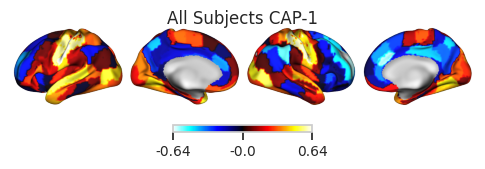

2026-09-10 13:29:33,007 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpry66vwxv.nii.gz]


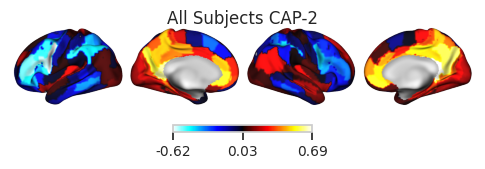

2026-09-10 13:29:33,705 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmp8kxbkih2.nii.gz]


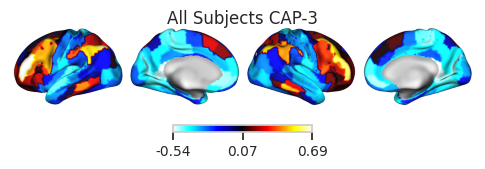

2026-09-10 13:29:34,457 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmp3q0kh83a.nii.gz]


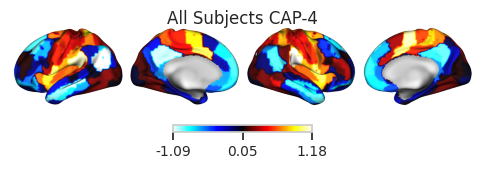

2026-09-10 13:29:35,137 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmp4jcvbcat.nii.gz]


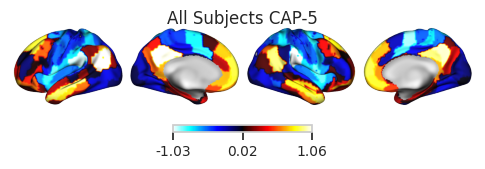

2026-09-10 13:29:35,887 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmpbkkm4mgb.nii.gz]


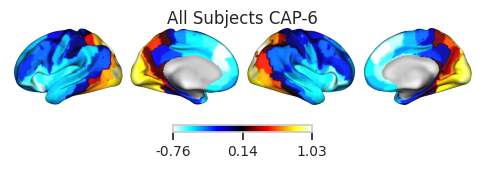

2026-09-10 13:29:36,589 neurocaps.analysis.cap._internals.surface [WARNING] TypeError raised by neuromaps due to changes in pathlib.py in Python 3.12 Converting NIfTI image into a temporary nii.gz file (which will be automatically deleted afterwards) [TEMP FILE: /tmp/tmphz8hikx5.nii.gz]


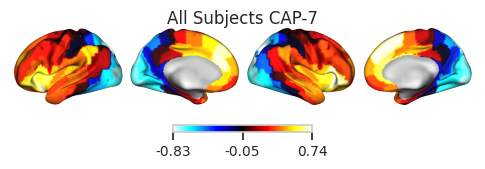

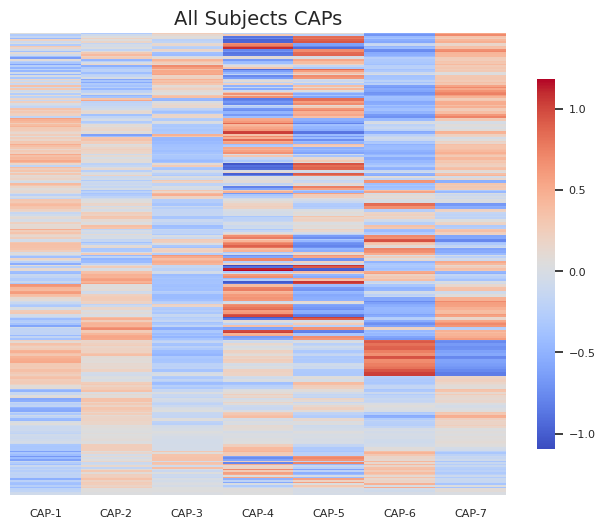

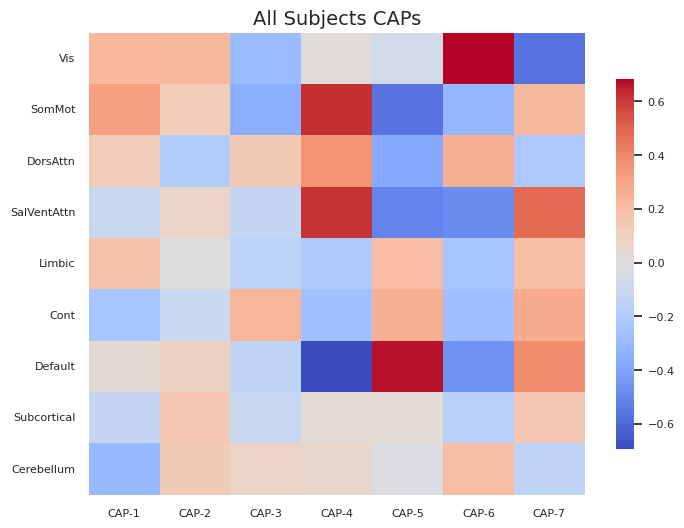

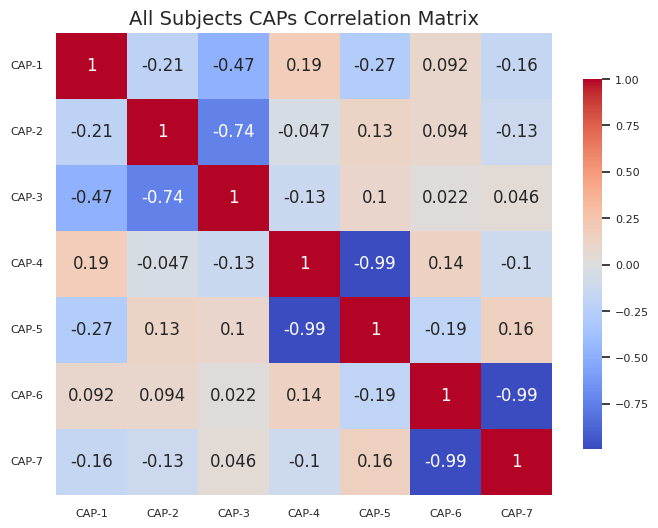

In [8]:
surface_kwargs = {**PlotDefaults.caps2surf(), "layout": "row", "size": (500, 100)}

radar_kwargs = {**PlotDefaults.caps2radar(), "height": 400, "width": 600}
radar_kwargs["radialaxis"] = {"range": [0, 0.8], "tickvals": [0.1, "", "", 0.8]}
radar_kwargs["legend"] = {"yanchor": "top", "y": 0.8, "x": 1.15}

plot_kwargs = {**PlotDefaults.caps2plot()}

corr_kwargs = {**PlotDefaults.caps2corr()}

cap_analysis.caps2surf(**surface_kwargs)
cap_analysis.caps2radar(**radar_kwargs)
cap_analysis.caps2plot(**plot_kwargs, visual_scope="nodes")
cap_analysis.caps2plot(**plot_kwargs)
# cap_analysis.caps2plot(**plot_kwargs, plot_options="outer_product")
cap_analysis.caps2corr(**corr_kwargs)

In [9]:
STATS_DATASETS_DIR = OUTPUT_ROOT / "06_statistics_datasets"

from scripts.prepare_statistical_datasets_utils import prepare_statistical_datasets
stats_datasets = prepare_statistical_datasets(
    clinical_csv_path = "./data/merged_clinical_metrics.csv",
    metrics_csv_path = str(METRICS_DIR / "all_metrics_long.csv"),
    qc_csv_path = str(subject_fd_qc_path),
    output_dir = str(STATS_DATASETS_DIR)
)

[INFO] Reading raw data...
[INFO] Processing and pivoting metrics data...
[INFO] Merging metrics, QC, and clinical data...
 -> Merged base table generated (total rows: 674)
[INFO] Generating cross-sectional table (HC vs PD-OFF)...
 -> Cross-sectional table generated (HC: 140, PD: 316)
[INFO] Generating longitudinal paired wide table (PD OFF vs ON)...
 -> Longitudinal paired table generated (subjects with both pre/post: 218)


In [10]:
import importlib
import scripts.statistics_ancova_lmm_utils
import scripts.statistics_ancova_lmm_plot_utils
importlib.reload(scripts.statistics_ancova_lmm_utils)
importlib.reload(scripts.statistics_ancova_lmm_plot_utils)
from scripts.statistics_ancova_lmm_utils import run_statistical_pipeline
from scripts.statistics_ancova_lmm_plot_utils import generate_all_visualizations
STATS_ANCOVA_LMM_DIR = OUTPUT_ROOT / "07_statistics_ANCOVA_LMM"

run_statistical_pipeline(
    cross_csv = str(STATS_DATASETS_DIR / "02_cross_sectional_base.csv"),
    long_wide_csv = str(STATS_DATASETS_DIR / "03_longitudinal_paired_wide.csv"),
    output_dir = str(STATS_ANCOVA_LMM_DIR)
)

generate_all_visualizations(
    data_dir = STATS_DATASETS_DIR,
    stats_dir = STATS_ANCOVA_LMM_DIR,
    output_dir = STATS_ANCOVA_LMM_DIR
)

[INFO] Running ANCOVA (Cross-sectional)...
[INFO] Running LMM (Longitudinal)...
[INFO] Results merged and saved to: outputs/PDNeuroCAPs/07_statistics_ANCOVA_LMM/all_cross_longitudinal_merged.csv
[SUCCESS] Statistical analysis complete! Results saved to: outputs/PDNeuroCAPs/07_statistics_ANCOVA_LMM
[INFO] Generating ANCOVA cross-sectional raincloud plots...
[INFO] Generating LMM longitudinal delta raincloud plots...
[INFO] Generating LMM residual diagnostic plots...
[SUCCESS] All visualizations complete! Figures saved to: outputs/PDNeuroCAPs/07_statistics_ANCOVA_LMM


In [11]:
import importlib
import scripts.statistics_correlation_utils
importlib.reload(scripts.statistics_correlation_utils)
from scripts.statistics_correlation_utils import run_correlation_pipeline

STATS_CORRELATION_DIR = OUTPUT_ROOT / "08_statistics_correlation"

run_correlation_pipeline(
    data_dir=STATS_DATASETS_DIR,
    output_dir=STATS_CORRELATION_DIR
)

[INFO] Starting correlation analysis (Spearman Partial Correlation)...
 -> Cross-sectional analysis complete (tested 71 features)
 -> Longitudinal analysis group [All_PD] complete (tested 71 delta features)
 -> Longitudinal analysis group [Responder] complete (tested 71 delta features)
 -> Longitudinal analysis group [Non-responder] complete (tested 71 delta features)

[SUCCESS] Correlation analysis complete!
Total tests performed: 284
Significant associations (p_FDR < 0.05): 1
Output summary file: outputs/PDNeuroCAPs/08_statistics_correlation/correlation_results_summary.csv


In [12]:
import importlib
import scripts.response_lmm_interaction_utils
importlib.reload(scripts.response_lmm_interaction_utils)

from scripts.response_lmm_interaction_utils import run_response_lmm_interaction_pipeline

LMM_INTERACTION_DIR = OUTPUT_ROOT / "09_response_lmm_interaction"
run_response_lmm_interaction_pipeline(
    data_dir = STATS_DATASETS_DIR,
    output_dir = LMM_INTERACTION_DIR
)

[INFO] Successfully read longitudinal wide table, total pairs: 218
[INFO] Clinical response defined (threshold: 30.0%): Responder=135, Non-responder=83
[INFO] Running interaction effect analysis on 71 imaging features...


/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_lmm_interaction_utils.py:291: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['Delta_UPDRS'] = delta_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_lmm_interaction_utils.py:292: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['PctChange_UPDRS'] = pct_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_lmm_interaction_utils.py:293: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `


[SUCCESS] Interaction effect (LMM) analysis complete!
Number of successfully fitted models: 71
Significant interaction features (p_FDR < 0.05): 1
Output summary directory: outputs/PDNeuroCAPs/09_response_lmm_interaction


In [13]:
import importlib
import scripts.response_llm_stratified_utils
importlib.reload(scripts.response_llm_stratified_utils)

from scripts.response_llm_stratified_utils import run_response_stratified_pipeline

STRATIFIED_LMM_DIR = OUTPUT_ROOT / "10_response_lmm_stratified"
run_response_stratified_pipeline(
    data_dir = STATS_DATASETS_DIR,
    output_dir = STRATIFIED_LMM_DIR
)

[INFO] Starting three-way interaction and gender stratified analysis...
[DEBUG] Total candidate numeric features: 71

--- Testing feature: counts_CAP-1 ---


/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_llm_stratified_utils.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['Delta_UPDRS'] = delta_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_llm_stratified_utils.py:347: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long['PctChange_UPDRS'] = pct_u
/media/linjh/Object/PD_Project/PD_CAP_Analysis/scripts/response_llm_stratified_utils.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra


--- Testing feature: counts_CAP-2 ---

--- Testing feature: counts_CAP-3 ---
[SUCCESS] Step 1 overall model saved -> 01_overall_3way_lmm_summary.csv
[SUCCESS] Step 2 gender stratified model saved -> 02_stratified_subcohort_lmm_summary.csv
